In [15]:
import os
from dotenv import load_dotenv

load_dotenv()
from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_aws import ChatBedrockConverse

model = ChatBedrockConverse(
    model_id="moonshotai.kimi-k2.5",
    region_name="ap-south-1"
)

print("Model initialized successfully.")

Model initialized successfully.


In [ ]:

class AgentState(TypedDict):
    messages: Annotated[list, add_messages] # Automatically appends new messages
    context_summary: str                    # Placeholder for future compression
    sql_query: str                          # Current SQL attempt
    sql_errors: List[str]                   # Track errors for the healing loop
    current_data: List[dict]                # Mock DB response
    viz_history: List[dict]                 # Stored chart configurations
    next_node: str                          # Routing decision
    
print("AgentState defined.")

AgentState defined.


In [ ]:
# Dummy DB Environment

DUMMY_SCHEMA = """
CREATE TABLE sales (
    id INT PRIMARY KEY,
    date TEXT,
    revenue REAL,
    region TEXT
);
-- Sample Data: 'North', 'South', 'East', 'West'
"""

def mock_db_execute(sql: str) -> dict:
    """Mock database that returns data or throws an error based on the SQL string."""
    sql_lower = sql.lower()

    if "users" in sql_lower or "employees" in sql_lower:
        return {"error": "Table does not exist. Only 'sales' table is available."}
    
    # Simulate success
    if "sales" in sql_lower:
        return {
            "data": [
                {"date": "2023-10-01", "revenue": 1500, "region": "North"},
                {"date": "2023-10-02", "revenue": 2100, "region": "South"},
                {"date": "2023-10-03", "revenue": 1800, "region": "East"}
            ]
        }
        
    return {"error": "Invalid SQL syntax."}

print("Mock environment ready.")

Mock environment ready.


In [ ]:


def context_manager(state: AgentState):
    """Pass-through for V1. In V2, this will compress state.messages."""
    return {"context_summary": "Recent chat context active."}

def supervisor_router(state: AgentState):
    """Determines if the query needs DB access or just chat."""
    last_message = state["messages"][-1].content
    

    sys_msg = SystemMessage(content="""
    You are a routing assistant. Read the user's input.
    If the user asks about data, metrics, charts, or sales, respond with EXACTLY the word: 'data'.
    If the user makes general conversation or greets you, respond with EXACTLY the word: 'chat'.
    Do not add any other words.
    """)
    
    response = model.invoke([sys_msg, HumanMessage(content=last_message)])
    decision = response.content.strip().lower()

    if "data" in decision:
        route = "data"
    else:
        route = "chat"
        
    return {"next_node": route}

def direct_chat(state: AgentState):
    """Handles standard conversational queries."""
    sys_msg = SystemMessage(content="You are a helpful data assistant. Keep answers brief.")
    response = model.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}

def sql_writer(state: AgentState):
    """Writes SQL based on the schema and previous errors."""
    last_message = state["messages"][0].content # Find the actual user query
    errors = state.get("sql_errors", [])
    
    prompt = f"Write a SQL query for this request: {last_message}\nSchema:\n{DUMMY_SCHEMA}\n"
    if errors:
        prompt += f"\nWARNING: Your previous attempts failed with these errors: {errors}\nFix the query."
        
    sys_msg = SystemMessage(content="Respond ONLY with the raw SQL string. No markdown, no formatting.")
    response = model.invoke([sys_msg, HumanMessage(content=prompt)])
    

    clean_sql = response.content.replace("```sql", "").replace("```", "").strip()
    return {"sql_query": clean_sql}

def sql_executor(state: AgentState):
    """Executes the SQL against our mock DB."""
    sql = state["sql_query"]
    print(f"--- [Executor Running SQL]: {sql}")
    
    result = mock_db_execute(sql)
    
    if "error" in result:

        current_errors = state.get("sql_errors", [])
        current_errors.append(result["error"])
        return {"sql_errors": current_errors}
    else:

        return {"current_data": result["data"], "sql_errors": []}

def data_formatter(state: AgentState):
    """Translates the raw JSON data into a natural language response."""
    data = state["current_data"]
    sys_msg = SystemMessage(content="Summarize this JSON data into a clean, readable sentence or two for the user.")
    prompt = f"Data: {data}"
    
    response = model.invoke([sys_msg, HumanMessage(content=prompt)])
    
    # We update both the messages (to show the user) and viz_history
    return {
        "messages": [response],
        "viz_history": [{"type": "text_summary", "data": data}]
    }

print("Nodes defined.")

Nodes defined.


In [ ]:


def route_from_supervisor(state: AgentState) -> Literal["direct_chat", "sql_writer"]:
    """Reads the router's decision from the state."""
    if state["next_node"] == "data":
        return "sql_writer"
    return "direct_chat"

def route_from_executor(state: AgentState) -> Literal["sql_writer", "data_formatter"]:
    """Implements the self-healing SQL loop."""
    errors = state.get("sql_errors", [])
    if len(errors) > 0:

        if len(errors) >= 3:
            print("--- [Maximum SQL retries reached]")
            return "data_formatter" 
        return "sql_writer" 
    return "data_formatter" 


builder = StateGraph(AgentState)

builder.add_node("context_manager", context_manager)
builder.add_node("supervisor_router", supervisor_router)
builder.add_node("direct_chat", direct_chat)
builder.add_node("sql_writer", sql_writer)
builder.add_node("sql_executor", sql_executor)
builder.add_node("data_formatter", data_formatter)


builder.add_edge(START, "context_manager")
builder.add_edge("context_manager", "supervisor_router")

builder.add_conditional_edges(
    "supervisor_router",
    route_from_supervisor,
    {
        "direct_chat": "direct_chat",
        "sql_writer": "sql_writer"
    }
)

builder.add_edge("direct_chat", END)


builder.add_edge("sql_writer", "sql_executor")
builder.add_conditional_edges(
    "sql_executor",
    route_from_executor,
    {
        "sql_writer": "sql_writer",        
        "data_formatter": "data_formatter" 
    }
)

# Formatter finishes the graph
builder.add_edge("data_formatter", END)

# Compile the engine
graph = builder.compile()
print("Graph compiled successfully.")

Graph compiled successfully.


In [ ]:
# Execution and Testing

def run_agent(query: str):
    print(f"\nUser Query: {query}")
    print("=" * 40)
    
    # Initialize empty state with the user's message
    initial_state = {
        "messages": [HumanMessage(content=query)],
        "sql_errors": []
    }
    
    # Stream the graph execution to see the steps
    for event in graph.stream(initial_state, stream_mode="updates"):
        for node_name, state_update in event.items():
            print(f"Node Executed: [{node_name}]")
            # Print the routing decision if we are at the router
            if node_name == "supervisor_router":
                print(f"  -> Decided Route: {state_update.get('next_node')}")
            # Print the final message if we are at the end
            if "messages" in state_update and node_name in ["direct_chat", "data_formatter"]:
                print(f"  -> Final Response: {state_update['messages'][-1].content}")

# Test 1: The 'Data' Path (Should trigger SQL flow)
run_agent("Can you show me the sales revenue data for the North region?")

# Test 2: The 'Chat' Path (Should skip SQL flow)
# run_agent("Hello! What kind of assistant are you?")

# Test 3: The 'Self-Healing' Path
# run_agent("Show me the names of our employees.")


User Query: Can you show me the sales revenue data for the North region?
Node Executed: [context_manager]
Node Executed: [supervisor_router]
  -> Decided Route: data
Node Executed: [sql_writer]
--- [Executor Running SQL]: SELECT revenue FROM sales WHERE region = 'North';
Node Executed: [sql_executor]
Node Executed: [data_formatter]
  -> Final Response:  From October 1-3, 2023, the North, South, and East regions generated $1,500, $2,100, and $1,800 in revenue respectively, totaling $5,400.


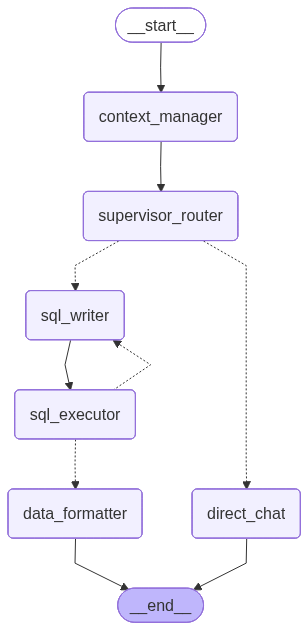

In [22]:

from IPython.display import Image, display


image_data = graph.get_graph().draw_mermaid_png()
display(Image(image_data))
